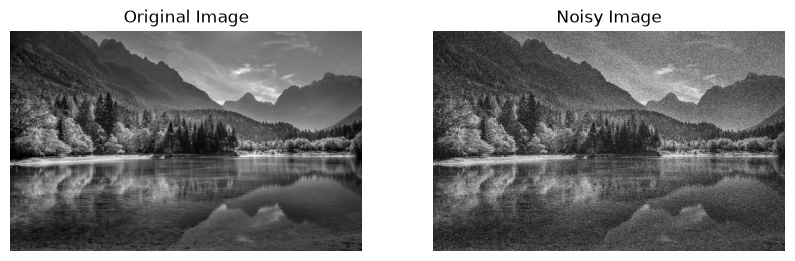

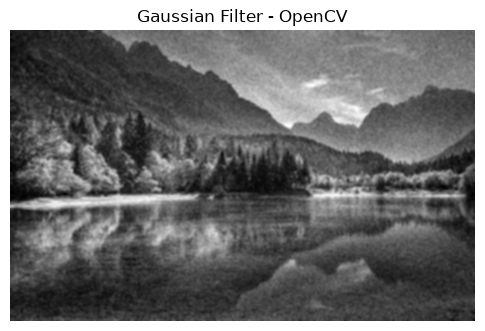

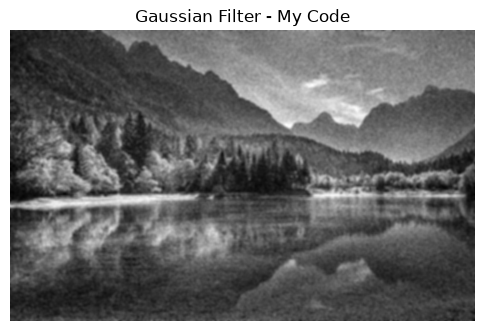

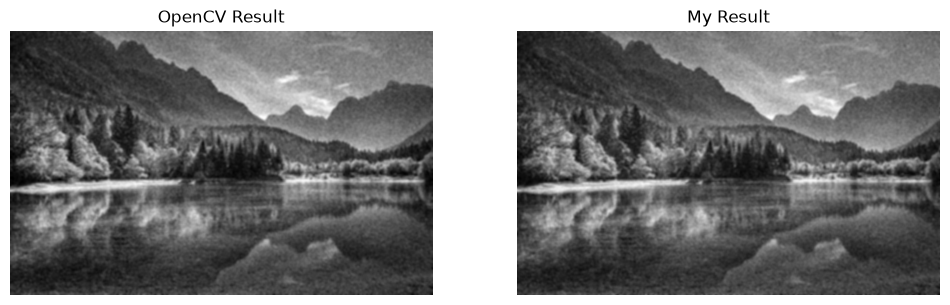

Original image size: (1200, 1920)
Noisy image size: (1200, 1920)
Filtered image size: (1200, 1920)


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Read the image
img = cv2.imread("wallpaperflare.com_wallpaper (2).jpg", cv2.IMREAD_GRAYSCALE)

# 2. Add random Gaussian noise
mean_value = 0
noise_sigma = 60
random_noise = np.random.normal(mean_value, noise_sigma, img.shape)

noisy_img = img.astype(np.float32) + random_noise
noisy_img = np.clip(noisy_img, 0, 255)
noisy_img = noisy_img.astype(np.uint8)

# 3. Show original and noisy image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_img, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.show()

# 4. Gaussian filter using OpenCV
opencv_result = cv2.GaussianBlur(noisy_img, (15, 15), 5)

plt.figure(figsize=(6, 6))
plt.imshow(opencv_result, cmap="gray")
plt.title("Gaussian Filter - OpenCV")
plt.axis("off")
plt.show()


# 5. Custom Gaussian filter implementation
def my_gaussian_filter(img, size=15, sigma=5):
    half = size // 2

    # Create 2D coordinate grid and Gaussian kernel
    x, y = np.mgrid[-half : half + 1, -half : half + 1]
    gaussian = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    gaussian = gaussian / np.sum(gaussian)

    # Pad image boundaries
    padded_img = np.pad(img, ((half, half), (half, half)), mode="edge")

    height, width = img.shape
    result = np.zeros((height, width), dtype=np.float32)

    # Spatial convolution
    for row in range(height):
        for col in range(width):
            small_part = padded_img[row : row + size, col : col + size]
            result[row, col] = np.sum(small_part * gaussian)

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)


# Apply custom filter
my_result = my_gaussian_filter(noisy_img, size=15, sigma=5)

# Display custom filter result
plt.figure(figsize=(6, 6))
plt.imshow(my_result, cmap="gray")
plt.title("Gaussian Filter - My Code")
plt.axis("off")
plt.show()

# 6. Compare both results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(opencv_result, cmap="gray")
plt.title("OpenCV Result")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(my_result, cmap="gray")
plt.title("My Result")
plt.axis("off")

plt.show()

# Check image sizes
print("Original image size:", img.shape)
print("Noisy image size:", noisy_img.shape)
print("Filtered image size:", my_result.shape)